# HW1 - Applied Quantitative Logistics

Instruction for submission:

- Please create a private GitHub repository then commit your solution to your repository.

- Deadline: **February 13, 2025, 11:59 pm.**

- Please replace **Your_Name** by your full-name : **[HW1_AQL]-YOUR_NAME**

### After the assigment is done, please, push it to a [private GitHub repository](https://docs.github.com/en/github/administering-a-repository/managing-repository-settings/setting-repository-visibility) and invite [Majid-Sohrabi](https://github.com/Majid-Sohrabi) [as collaborators](https://docs.github.com/en/account-and-profile/setting-up-and-managing-your-github-user-account/managing-access-to-your-personal-repositories/inviting-collaborators-to-a-personal-repository).

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import random

## Binary SA

**Problem:** Min One
$$
\min{z} = f(x) = \begin{equation*}
\sum_{i=1}^n x_i \end{equation*}
$$

$$
x_i \in \{0, 1\}
$$

Improve SA quality:

Application in high dimension (more complex) problems when one sulution does not work well.

- How to improve?

### 1. Making parallel SA under one algorithm (no interaction between solutions)

<img src="Picture1.png" width="400">


Note: In this case the best solution out of 3 will be best solution for the next iteration.


Solution 1 Iteration History:
Iteration 1: Cost = -244.0000
Iteration 2: Cost = -254.0000
Iteration 3: Cost = -254.0000
Iteration 4: Cost = -254.0000
Iteration 5: Cost = -254.0000
Iteration 6: Cost = -254.0000
Iteration 7: Cost = -254.0000
Iteration 8: Cost = -254.0000
Iteration 9: Cost = -254.0000
Iteration 10: Cost = -254.0000
Iteration 11: Cost = -254.0000
Iteration 12: Cost = -254.0000
Iteration 13: Cost = -254.0000
Iteration 14: Cost = -254.0000
Iteration 15: Cost = -254.0000
Iteration 16: Cost = -254.0000
Iteration 17: Cost = -254.0000
Iteration 18: Cost = -254.0000
Iteration 19: Cost = -254.0000
Iteration 20: Cost = -254.0000
Iteration 21: Cost = -254.0000
Iteration 22: Cost = -254.0000
Iteration 23: Cost = -254.0000
Iteration 24: Cost = -254.0000
Iteration 25: Cost = -254.0000
Iteration 26: Cost = -254.0000
Iteration 27: Cost = -254.0000
Iteration 28: Cost = -254.0000
Iteration 29: Cost = -254.0000
Iteration 30: Cost = -254.0000
Iteration 31: Cost = -254.0000
Iteration 32: Cos

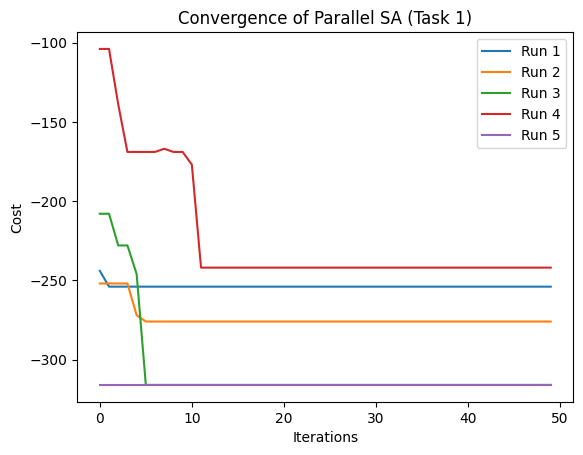

([0, 0, 0, 1, 0, 1, 1, 1, 0, 1], -316)

In [3]:
import random
import math
import matplotlib.pyplot as plt

def cost_function(solution, values, weights, W, alpha):
    total_value = sum(x * v for x, v in zip(solution, values))
    total_weight = sum(x * w for x, w in zip(solution, weights))
    penalty = alpha * max(total_weight - W, 0)
    return -total_value + penalty  # Negative because we want to maximize value

def task1_parallel_sa(num_solutions, num_iterations, values, weights, W, alpha, T0, alpha_cooling):
    def generate_neighbor(solution):
        neighbor = solution.copy()
        idx = random.randint(0, len(solution) - 1)
        neighbor[idx] = 1 - neighbor[idx]  # Flip a random bit
        return neighbor

    best_overall_solution = None
    best_overall_cost = float('inf')
    convergence_data = []

    for i in range(num_solutions):
        solution = [random.randint(0, 1) for _ in range(len(values))]
        cost = cost_function(solution, values, weights, W, alpha)
        T = T0
        local_convergence = []

        print(f"\nSolution {i+1} Iteration History:")
        for iteration in range(num_iterations):
            neighbor = generate_neighbor(solution)
            neighbor_cost = cost_function(neighbor, values, weights, W, alpha)

            if neighbor_cost < cost or random.random() < math.exp((cost - neighbor_cost) / T):
                solution, cost = neighbor, neighbor_cost

            T *= alpha_cooling
            local_convergence.append(cost)
            print(f"Iteration {iteration + 1}: Cost = {cost:.4f}")

        if cost < best_overall_cost:
            best_overall_solution = solution
            best_overall_cost = cost

        convergence_data.append(local_convergence)

    print(f"\nTask 1 - Best Solution: {best_overall_solution}, Cost: {best_overall_cost}")

    for i, conv in enumerate(convergence_data):
        plt.plot(conv, label=f"Run {i+1}")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Convergence of Parallel SA (Task 1)")
    plt.legend()
    plt.show()

    return best_overall_solution, best_overall_cost

# Example Usage
n = 10  # Number of items
values = [random.randint(10, 100) for _ in range(n)]
weights = [random.randint(5, 20) for _ in range(n)]
W = 50  # Knapsack capacity
alpha = 10  # Penalty coefficient

task1_parallel_sa(num_solutions=5, num_iterations=50, values=values, weights=weights, W=W, alpha=alpha, T0=10, alpha_cooling=0.9)

### 2. Making SA based on population by interaction.

<img src="Picture2.png" width="400">

Note: In this case at each time we make several neighbours, then compare the best neighbours by current solutions.

Iteration History:
Iteration 1: Cost = -72.0000
Iteration 2: Cost = -234.0000
Iteration 3: Cost = -321.0000
Iteration 4: Cost = -321.0000
Iteration 5: Cost = -321.0000
Iteration 6: Cost = -321.0000
Iteration 7: Cost = -321.0000
Iteration 8: Cost = -321.0000
Iteration 9: Cost = -321.0000
Iteration 10: Cost = -321.0000
Iteration 11: Cost = -321.0000
Iteration 12: Cost = -321.0000
Iteration 13: Cost = -321.0000
Iteration 14: Cost = -321.0000
Iteration 15: Cost = -321.0000
Iteration 16: Cost = -321.0000
Iteration 17: Cost = -321.0000
Iteration 18: Cost = -321.0000
Iteration 19: Cost = -321.0000
Iteration 20: Cost = -321.0000
Iteration 21: Cost = -321.0000
Iteration 22: Cost = -321.0000
Iteration 23: Cost = -321.0000
Iteration 24: Cost = -321.0000
Iteration 25: Cost = -321.0000
Iteration 26: Cost = -321.0000
Iteration 27: Cost = -321.0000
Iteration 28: Cost = -321.0000
Iteration 29: Cost = -321.0000
Iteration 30: Cost = -321.0000
Iteration 31: Cost = -321.0000
Iteration 32: Cost = -321.0000

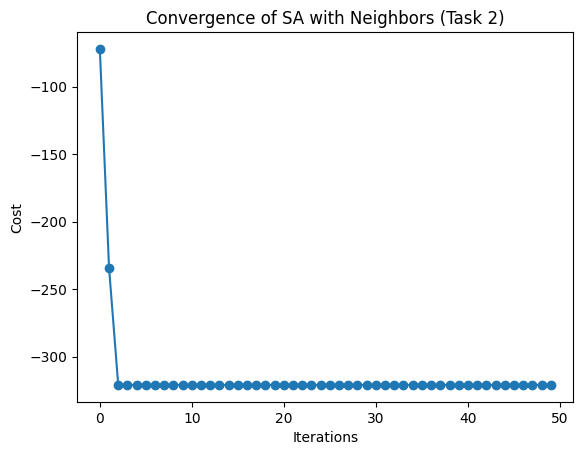

([0, 0, 1, 1, 1, 0, 0, 1, 1, 0], -321)

In [4]:
def task2_sa_with_neighbors(num_neighbors, num_iterations, values, weights, W, alpha, T0, alpha_cooling):
    def generate_neighbor(solution):
        neighbor = solution.copy()
        idx = random.randint(0, len(solution) - 1)
        neighbor[idx] = 1 - neighbor[idx]  # Flip a random bit
        return neighbor

    # Initialize a single solution
    solution = [random.randint(0, 1) for _ in range(len(values))]
    cost = cost_function(solution, values, weights, W, alpha)
    T = T0
    best_solution = solution
    best_cost = cost
    convergence_data = []

    print("Iteration History:")
    for iteration in range(1, num_iterations + 1):
        # Generate multiple neighbors
        neighbors = [generate_neighbor(solution) for _ in range(num_neighbors)]
        neighbor_costs = [cost_function(neighbor, values, weights, W, alpha) for neighbor in neighbors]

        # Find the best neighbor
        best_neighbor_index = neighbor_costs.index(min(neighbor_costs))
        best_neighbor = neighbors[best_neighbor_index]
        best_neighbor_cost = neighbor_costs[best_neighbor_index]

        # Compare with current solution using SA acceptance criteria
        if best_neighbor_cost < cost or random.random() < math.exp((cost - best_neighbor_cost) / T):
            solution, cost = best_neighbor, best_neighbor_cost

        # Update global best solution
        if cost < best_cost:
            best_solution = solution
            best_cost = cost

        T *= alpha_cooling
        convergence_data.append(cost)
        print(f"Iteration {iteration}: Cost = {cost:.4f}")

    print(f"\nTask 2 - Best Solution: {best_solution}, Cost: {best_cost:.4f}")

    # Plot convergence
    plt.plot(convergence_data, marker='o', linestyle='-')
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Convergence of SA with Neighbors (Task 2)")
    plt.show()

    return best_solution, best_cost

# Example Usage
n = 10  # Number of items
values = [random.randint(10, 100) for _ in range(n)]
weights = [random.randint(5, 20) for _ in range(n)]
W = 50  # Knapsack capacity
alpha = 10  # Penalty coefficient

task2_sa_with_neighbors(num_neighbors=5, num_iterations=50, values=values, weights=weights, W=W, alpha=alpha, T0=10, alpha_cooling=0.9)

### 3. Now let's combine steps 1 and 2 together in one algorithm.

In this case, for SA based on population with interaction.

<img src="Picture3.png" width="400">

Note: Now we have 3 parents and 12 neighbours, then compare each parent by all neighbours by SA mechanism.

- SA based on population steps:

1. Generate initial population and evaluate
2. Define the best solution out of them
3. Adjust the initial temprature $T=T0$
4. Repeat steps *4.1* to *4.4* for a specific number of iterations
    
    4.1. For each member of the population generate specific number of neighbours.
    
    4.2. Sort all neighbours and the best members to the number of population are elected.
    
    4.3. each member of the population will be compared by these winner neighbours
    
    4.4 Update the best solution ever found

5. Reduce the temprature and return to step 4 (if it's needed)

Iteration History:
Iteration 1: Best Cost = -241.0000
Iteration 2: Best Cost = -294.0000
Iteration 3: Best Cost = -343.0000
Iteration 4: Best Cost = -343.0000
Iteration 5: Best Cost = -343.0000
Iteration 6: Best Cost = -343.0000
Iteration 7: Best Cost = -343.0000
Iteration 8: Best Cost = -343.0000
Iteration 9: Best Cost = -343.0000
Iteration 10: Best Cost = -343.0000
Iteration 11: Best Cost = -343.0000
Iteration 12: Best Cost = -343.0000
Iteration 13: Best Cost = -343.0000
Iteration 14: Best Cost = -343.0000
Iteration 15: Best Cost = -343.0000
Iteration 16: Best Cost = -343.0000
Iteration 17: Best Cost = -343.0000
Iteration 18: Best Cost = -343.0000
Iteration 19: Best Cost = -343.0000
Iteration 20: Best Cost = -343.0000
Iteration 21: Best Cost = -343.0000
Iteration 22: Best Cost = -343.0000
Iteration 23: Best Cost = -343.0000
Iteration 24: Best Cost = -343.0000
Iteration 25: Best Cost = -343.0000
Iteration 26: Best Cost = -343.0000
Iteration 27: Best Cost = -343.0000
Iteration 28: Best

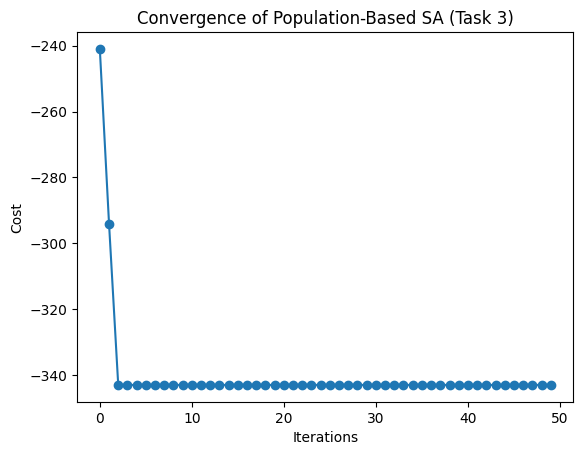

([0, 1, 1, 0, 1, 0, 0, 0, 1, 1], -343)

In [5]:
def cost_function(solution, values, weights, W, alpha):
    total_value = sum(x * v for x, v in zip(solution, values))
    total_weight = sum(x * w for x, w in zip(solution, weights))
    penalty = alpha * max(total_weight - W, 0)
    return -total_value + penalty  # Negative because we want to maximize value

def task3_population_sa(num_solutions, num_neighbors, num_iterations, values, weights, W, alpha, T0, alpha_cooling):
    def generate_neighbor(solution):
        neighbor = solution.copy()
        idx = random.randint(0, len(solution) - 1)
        neighbor[idx] = 1 - neighbor[idx]  # Flip a random bit
        return neighbor

    # Initialize population
    population = [[random.randint(0, 1) for _ in range(len(values))] for _ in range(num_solutions)]
    costs = [cost_function(solution, values, weights, W, alpha) for solution in population]
    T = T0
    best_overall_solution = None
    best_overall_cost = float('inf')
    convergence_data = []

    print("Iteration History:")

    for iteration in range(1, num_iterations + 1):
        all_neighbors = []
        for i in range(num_solutions):
            # Generate neighbors for each solution in the population
            neighbors = [generate_neighbor(population[i]) for _ in range(num_neighbors)]
            all_neighbors.extend(neighbors)

        # Combine current population and neighbors
        all_candidates = population + all_neighbors
        all_costs = [cost_function(solution, values, weights, W, alpha) for solution in all_candidates]

        # Sort candidates by cost (ascending order)
        sorted_indices = sorted(range(len(all_costs)), key=lambda k: all_costs[k])
        sorted_candidates = [all_candidates[i] for i in sorted_indices]
        sorted_costs = [all_costs[i] for i in sorted_indices]

        # Select the top `num_solutions` candidates
        population = sorted_candidates[:num_solutions]
        costs = sorted_costs[:num_solutions]

        # Update global best solution
        if costs[0] < best_overall_cost:
            best_overall_solution = population[0]
            best_overall_cost = costs[0]

        # Append best cost for convergence plot
        convergence_data.append(best_overall_cost)

        # Print iteration progress
        print(f"Iteration {iteration}: Best Cost = {best_overall_cost:.4f}")

        # Cool temperature
        T *= alpha_cooling

    print(f"\nTask 3 - Best Solution: {best_overall_solution}, Cost: {best_overall_cost:.4f}")

    # Plot convergence
    plt.plot(convergence_data, marker='o', linestyle='-')
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Convergence of Population-Based SA (Task 3)")
    plt.show()

    return best_overall_solution, best_overall_cost

# Example Usage
n = 10  # Number of items
values = [random.randint(10, 100) for _ in range(n)]
weights = [random.randint(5, 20) for _ in range(n)]
W = 50  # Knapsack capacity
alpha = 10  # Penalty coefficient

task3_population_sa(num_solutions=5, num_neighbors=15, num_iterations=50, values=values, weights=weights, W=W, alpha=alpha, T0=10, alpha_cooling=0.95)